<a href="https://colab.research.google.com/github/Non8q/IT326-Adult-Census-Income/blob/main/Phase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv("Preprocessed_dataset.csv")

### 1- Define Features (X) and Target (y)

In [20]:
X = df.drop('income', axis=1)
y = df['income']

### 2- Split the data (80% Train, 20% Test)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# **# Part 1: Classification using Decision Tree**

### 3- Build the model using Entropy (Same as the other group but with better depth control)

In [21]:
clf = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

### Model Evaluation



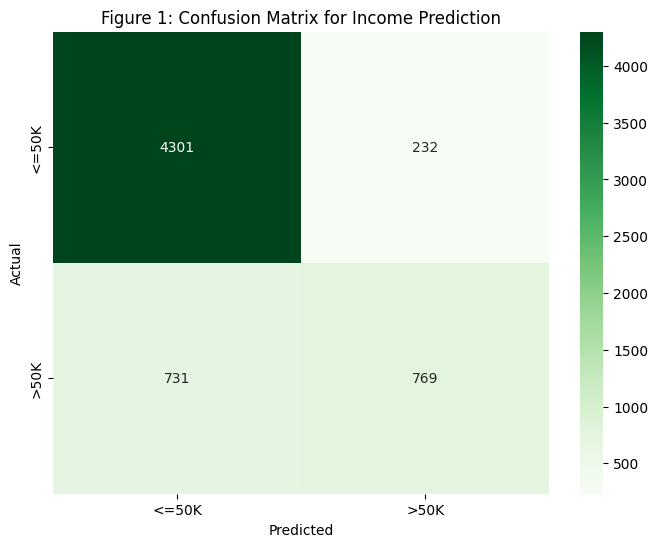

In [26]:
y_pred = clf.predict(X_test)
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
plt.title('Figure 1: Confusion Matrix for Income Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


### Visualize the Decision Tree

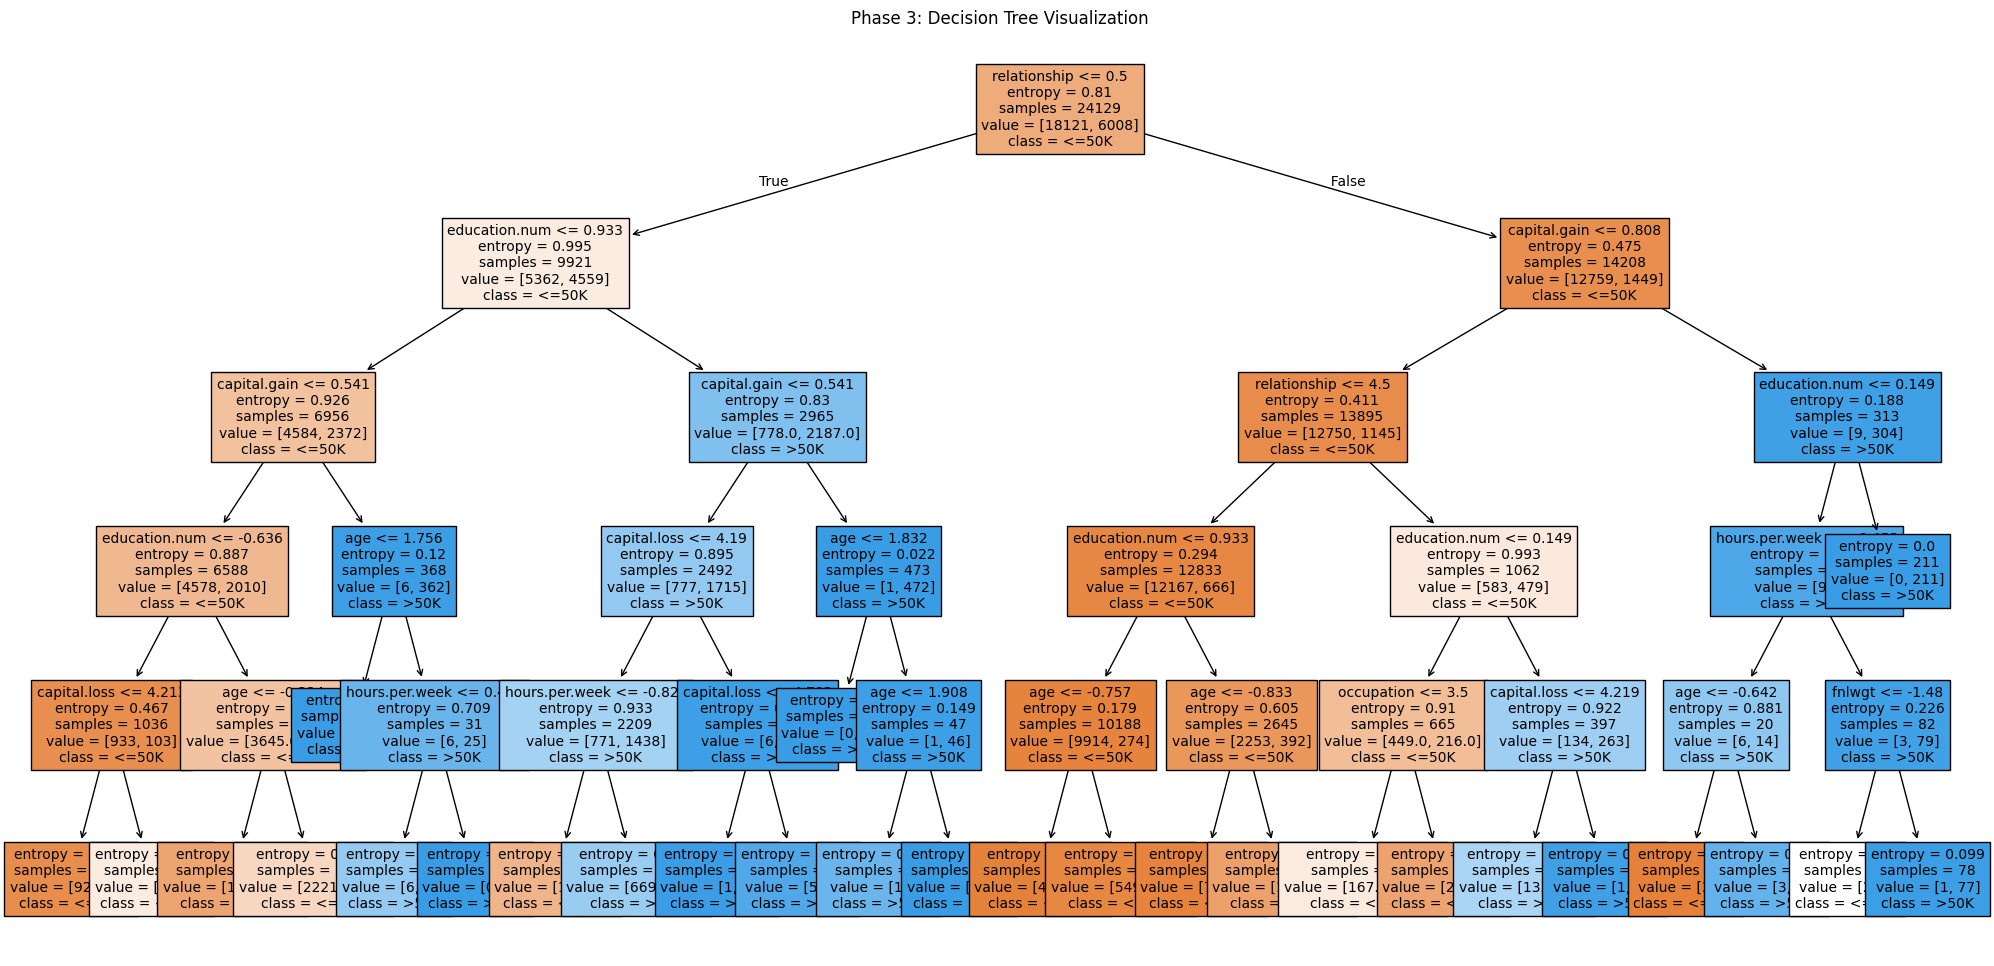

In [14]:
plt.figure(figsize=(25,12))
plot_tree(clf, feature_names=X.columns, class_names=['<=50K', '>50K'], filled=True, fontsize=10)
plt.title("Phase 3: Decision Tree Visualization")
plt.show()

# **# Part 2: Clustering (K-Means)**

### Use the Elbow Method to find the optimal number of clusters (K)

In [28]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)



### Plot the Elbow Graph

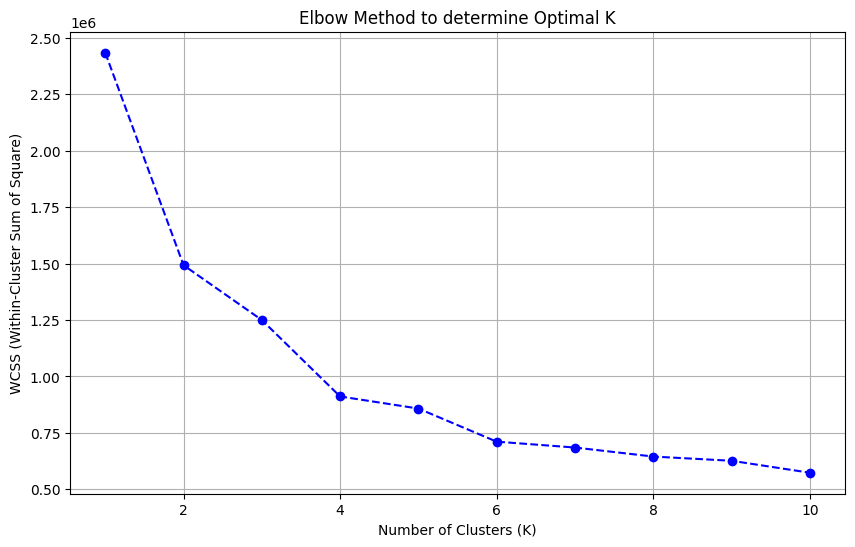

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', color='blue', linestyle='--')
plt.title('Elbow Method to determine Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Square)')
plt.grid(True)
plt.show()

### Apply K-Means with K=3 (Optimal based on common patterns)

In [17]:
final_kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
df['Cluster_Label'] = final_kmeans.fit_predict(X)

### Final Output: Show samples count in each cluster

In [18]:
print("\n--- Clustering Analysis ---")
print("Number of records in each Cluster:\n", df['Cluster_Label'].value_counts())


--- Clustering Analysis ---
Number of records in each Cluster:
 Cluster_Label
1    24168
0     4012
2     1982
Name: count, dtype: int64


In [31]:
kmeans_final = KMeans(n_clusters=3, init='k-means++', random_state=42)
df['Cluster'] = kmeans_final.fit_predict(X)
# --- [Cluster Characterization] ---
cluster_analysis = df.groupby('Cluster').mean()
print("\n--- Summary of Clusters (Mean Values) ---")
print(cluster_analysis)


--- Summary of Clusters (Mean Values) ---
              age  workclass    fnlwgt  education  education.num  \
Cluster                                                            
0       -0.074389   2.170288  0.380711   8.803436      -0.548331   
1       -0.017422   2.195942 -0.027142  10.150551       0.144230   
2        0.026654   2.206492 -0.026346  10.716298      -0.061549   

         marital.status  occupation  relationship      race       sex  \
Cluster                                                                 
0              2.757453    5.889843      1.435574  3.386559  0.700354   
1              2.663212    9.636868      1.475808  3.679705  0.636649   
2              2.477279    2.489710      1.361602  3.717472  0.709254   

         capital.gain  capital.loss  hours.per.week  native.country    income  \
Cluster                                                                         
0           -0.035606     -0.060049       -0.021297       15.377463  0.188479   
1      

### Save the results with clusters for final interpretation

In [19]:
df.to_csv("Final_Project_Results.csv", index=False)
print("\nFinal results saved to 'Final_Project_Results.csv'")


Final results saved to 'Final_Project_Results.csv'
